## 1. Import Libraries & modules

In [2]:
import pandas as pd
import itertools
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from lightgbm import LGBMClassifier
import os
import seaborn as sns
from wordcloud import WordCloud

## 2. Import & Explore Data

In [3]:
df = pd.read_csv("malicious_url.csv")

print("Dataframe shape: ", df.shape, "\n")
print("Types or url: ", df.type.value_counts())

df.head()

Dataframe shape:  (651191, 2) 

Types or url:  type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


**Plotting Wordcloud**

In [4]:
# Create dataframes for each type of URL
df_benign = df[df.type == 'benign']
df_defacement = df[df.type == 'defacement']
df_phishing = df[df.type == 'phishing']
df_malware = df[df.type == 'malware']

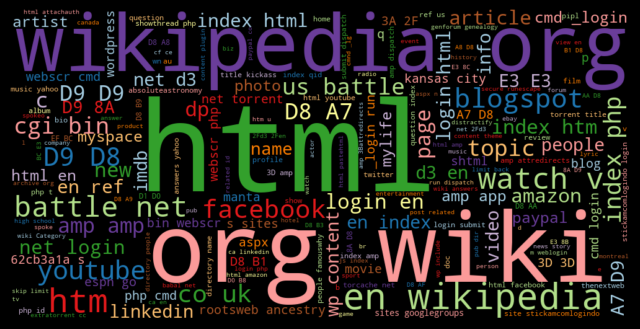

In [5]:
# WordCloud for benign
benign_url = ' '.join(i for i in df_benign.url)
wordcloud = WordCloud(width=1000, height=500, colormap='Paired').generate(benign_url)
plt.figure(figsize=(8, 5), facecolor='k')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

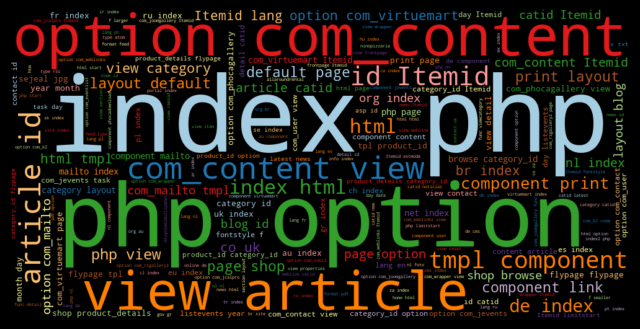

In [6]:
# WordCloud for defacement
defacement_url = ' '.join(i for i in df_defacement.url)
wordcloud = WordCloud(width=1000, height=500, colormap='Paired').generate(defacement_url)
plt.figure(figsize=(8, 5), facecolor='k')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

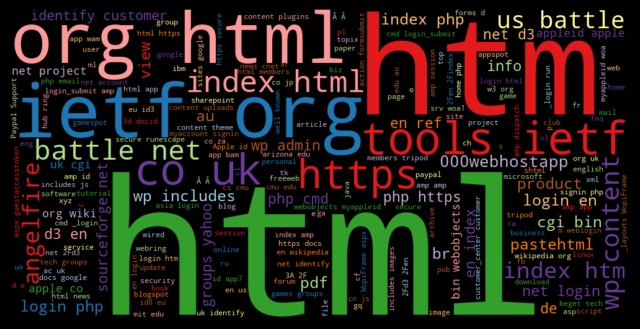

In [7]:
# WordCloud for phishing
phishing_url = ' '.join(i for i in df_phishing.url)
wordcloud = WordCloud(width=1000, height=500, colormap='Paired').generate(phishing_url)
plt.figure(figsize=(8, 5), facecolor='k')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

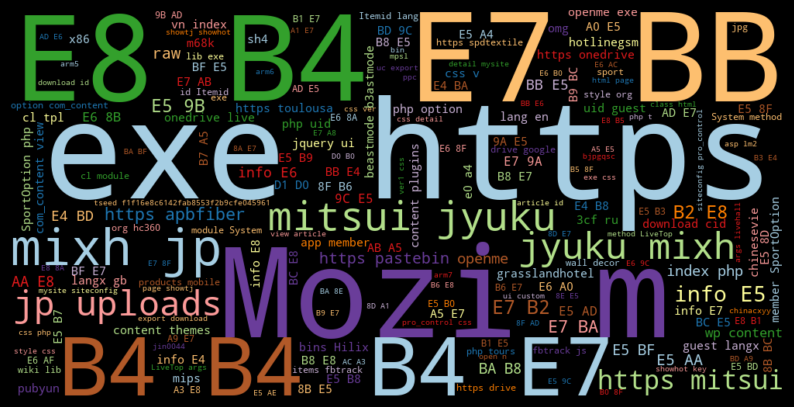

In [8]:
# WordCloud for malware
malware_url = ' '.join(i for i in df_malware.url)
wordcloud = WordCloud(width=1000, height=500, colormap='Paired').generate(malware_url)
plt.figure(figsize=(10, 6), facecolor='k')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**Feature Engineering**

In [9]:
import ipaddress
from urllib.parse import urlparse

def have_ip(url):
    try:
        host = urlparse(url).hostname  # lấy phần host
        if host is None:
            return 0
        
        # bỏ ngoặc vuông nếu là IPv6
        host = host.strip("[]")
        
        ipaddress.ip_address(host)  # thử parse
        return 1
    except ValueError:
        return 0
    
df['use_of_ip'] = df['url'].apply(lambda i: have_ip(i))

In [10]:
import re
def abnormal_url(url):
    hostname = urlparse(url).hostname
    hostname = str(hostname)
    match = re.search(hostname, url)
    return 1 if match else 0
    
df['abnormal_url'] = df['url'].apply(lambda i: abnormal_url(i))    

In [11]:
from googlesearch import search

def google_index(url):
    site = search(url, 5)
    return 1 if site else 0

df['google_index'] = df['url'].apply(lambda i: google_index(i))

def count_dot(url):
    return url.count('.')

df['Count_dot'] = df['url'].apply(lambda i: count_dot(i))

In [12]:
df.head()

,url,type,use_of_ip,abnormal_url,google_index,Count_dot
0,br-icloud.com.br,phishing,0,0,1,2
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2


In [13]:
def count_www(url):
    return url.count('www')

df['count_www'] = df['url'].apply(lambda i: count_www(i))

def count_atrate(url):
    return url.count('@')

df['count_atrate'] = df['url'].apply(lambda i: count_atrate(i))

def count_dir(url):
    path = urlparse(url).path
    return path.count('/')

df['count_dir'] = df['url'].apply(lambda i: count_dir(i))

def count_embed_domain(url):
    path = urlparse(url).path
    return path.count('//')

df['count_embed_domain'] = df['url'].apply(lambda i: count_embed_domain(i))

In [14]:
import urlexpander

def shortening_service(url):
    return 1 if urlexpander.is_short(url) else 0
    
df['short_url'] = df['url'].apply(lambda i: shortening_service(i))

In [15]:
def count_https(url):
    return url.count('https')

df['count_https'] = df['url'].apply(lambda i: count_https(i))

def count_http(url):
    return url.count('http')

df['count_http'] = df['url'].apply(lambda i: count_http(i))

In [16]:
def count_percent(url):
    return url.count('%')

df['count_percent'] = df['url'].apply(lambda i: count_percent(i))

def count_question(url):
    return url.count('?')

df['count_question'] = df['url'].apply(lambda i: count_question(i))


def count_hyphen(url):
    return url.count('-')

df['count_hyphen'] = df['url'].apply(lambda i: count_hyphen(i))


def count_equal(url):
    return url.count('=')

df['count_equal'] = df['url'].apply(lambda i: count_equal(i))

In [17]:
def url_length(url):
    return len(str(url))

df['url_length'] = df['url'].apply(lambda i: url_length(i))

def hostname_length(url):
    return len(urlparse(url).netloc)

df['hostname_length'] = df['url'].apply(lambda i: hostname_length(i))

In [21]:
def suspicious_words(url):
    match = re.search('PayPal|login|signin|bank|account|update|free|lucky|service|bonus|ebayisapi|webscr', 
                      url, re.IGNORECASE)
    return 1 if match else 0

df['suspicious_words'] = df['url'].apply(lambda i: suspicious_words(i))

def count_letter(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters += 1
    return letters

df['count_letter'] = df['url'].apply(lambda i: count_letter(i))

def count_digit(url):
    digits = 0
    for i in url:
        if i.isnumeric():
            digits += 1
    return digits

df['count_digits'] = df['url'].apply(lambda i: count_digit(i))

In [ ]:
from tld import get_tld
import os.path

def fd_length(url):
    path = urlparse(url).path
    try:
        return len(path.split('/')[1])
    except:
        return 0
    
df['fd_length'] = df['url'].apply(lambda i: fd_length(i))